# Taller 9 Jose Quintana 00343500
# bloque0_setup.py

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
print('pandas version:', pd.__version__)
print('matplotlib importado correctamente')
print('Todo listo para el taller')


pandas version: 3.0.2
matplotlib importado correctamente
Todo listo para el taller


# bloque1_dataframe
**Ejercicio 1.1 — Crear el DataFrame**

In [4]:
import pandas as pd
# Diccionario de Python: clave = nombre de columna, lista = datos
datos = {
'reactor': ['R1','R1','R1','R2','R2','R2','R3','R3'],
'turno': ['manana','tarde','noche','manana','tarde','noche','manana','tarde'],
'temperatura': [85, 92, 78, 95, 88, 91, 76, 83],
'eficiencia': [91.2, 87.5, 94.1, 83.3, 89.7, 85.0, 96.4, 92.8],
'incidentes': [0, 1, 0, 2, 0, 1, 0, 0]
}
# pd.DataFrame() convierte el diccionario en tabla
df = pd.DataFrame(datos)
print(df)
print()
print()
print('--- Filas y columnas ---')
print(df.shape)
print('--- Tipo de dato de cada columna ---')
print(df.dtypes)
print('--- Estadisticas basicas ---')
print(df.describe())

  reactor   turno  temperatura  eficiencia  incidentes
0      R1  manana           85        91.2           0
1      R1   tarde           92        87.5           1
2      R1   noche           78        94.1           0
3      R2  manana           95        83.3           2
4      R2   tarde           88        89.7           0
5      R2   noche           91        85.0           1
6      R3  manana           76        96.4           0
7      R3   tarde           83        92.8           0


--- Filas y columnas ---
(8, 5)
--- Tipo de dato de cada columna ---
reactor            str
turno              str
temperatura      int64
eficiencia     float64
incidentes       int64
dtype: object
--- Estadisticas basicas ---
       temperatura  eficiencia  incidentes
count     8.000000    8.000000    8.000000
mean     86.000000   90.000000    0.500000
std       6.761234    4.524221    0.755929
min      76.000000   83.300000    0.000000
25%      81.750000   86.875000    0.000000
50%      86.500000

# bloque2_procesar.py
**Ejercicio 2.1 — Seleccionar columnas**

In [7]:
# Una sola columna (devuelve una Serie — como una lista con etiquetas):
print()
print(df['temperatura'])
# Dos columnas a la vez (devuelve un DataFrame):
print()
print(df[['reactor', 'eficiencia']])
# Ver solo las primeras 3 filas:
print()
print(df.head(3))
# Imprime solo la columna 'turno':
print()
print(df['turno'])
# Imprime las columnas 'reactor' e 'incidentes' juntas:
print()
print(df[['reactor','incidentes']])


0    85
1    92
2    78
3    95
4    88
5    91
6    76
7    83
Name: temperatura, dtype: int64

  reactor  eficiencia
0      R1        91.2
1      R1        87.5
2      R1        94.1
3      R2        83.3
4      R2        89.7
5      R2        85.0
6      R3        96.4
7      R3        92.8

  reactor   turno  temperatura  eficiencia  incidentes
0      R1  manana           85        91.2           0
1      R1   tarde           92        87.5           1
2      R1   noche           78        94.1           0

0    manana
1     tarde
2     noche
3    manana
4     tarde
5     noche
6    manana
7     tarde
Name: turno, dtype: str

  reactor  incidentes
0      R1           0
1      R1           1
2      R1           0
3      R2           2
4      R2           0
5      R2           1
6      R3           0
7      R3           0


**Ejercicio 2.2 — Filtrar filas con una condicion**

In [15]:
# Quiero las filas donde temperatura supera 88.
# df['temperatura'] > 88 produce True/False para cada fila.
# df[ ... ] conserva solo las filas donde el resultado es True.
calientes = df[ df['temperatura'] > 88 ]
print('Mediciones con temperatura mayor a 88:')
print(calientes)

print("Filtro 1: filas donde el turno es exactamente 'manana'")
# Para comparar texto usa == (doble igual)
manana = df[ df['turno'] == "manana" ]
print('Turno manana:')
print(manana)
print("Filtro 2: filas donde no hubo ningun incidente (incidentes == 0)")
sin_incidentes = df[df["incidentes"]==0]
print('Sin incidentes:')
print(sin_incidentes)

Mediciones con temperatura mayor a 88:
  reactor   turno  temperatura  eficiencia  incidentes
1      R1   tarde           92        87.5           1
3      R2  manana           95        83.3           2
5      R2   noche           91        85.0           1
Filtro 1: filas donde el turno es exactamente 'manana'
Turno manana:
  reactor   turno  temperatura  eficiencia  incidentes
0      R1  manana           85        91.2           0
3      R2  manana           95        83.3           2
6      R3  manana           76        96.4           0
Filtro 2: filas donde no hubo ningun incidente (incidentes == 0)
Sin incidentes:
  reactor   turno  temperatura  eficiencia  incidentes
0      R1  manana           85        91.2           0
2      R1   noche           78        94.1           0
4      R2   tarde           88        89.7           0
6      R3  manana           76        96.4           0
7      R3   tarde           83        92.8           0


**Ejercicio 2.3 — Calcular estadisticas por grupo con groupby**

In [8]:
# Temperatura promedio de cada reactor:
promedio_temp = df.groupby('reactor')['temperatura'].mean()
print('Temperatura promedio por reactor:')
print(promedio_temp)

print()
print("1. Eficiencia PROMEDIO por turno (manana, tarde, noche):")
# groupby 'turno', columna 'eficiencia', funcion .mean()
ef_turno = df.groupby("turno")["eficiencia"].mean()
print('Eficiencia promedio por turno:')
print(ef_turno)
print()
print("2. Total de incidentes por reactor:")
# groupby 'reactor', columna 'incidentes', funcion .sum()
inc_reactor = df.groupby("reactor")["incidentes"].sum()
print('Total incidentes por reactor:')
print(inc_reactor)


Temperatura promedio por reactor:
reactor
R1    85.000000
R2    91.333333
R3    79.500000
Name: temperatura, dtype: float64

1. Eficiencia PROMEDIO por turno (manana, tarde, noche):
Eficiencia promedio por turno:
turno
manana    90.30
noche     89.55
tarde     90.00
Name: eficiencia, dtype: float64

2. Total de incidentes por reactor:
Total incidentes por reactor:
reactor
R1    1
R2    3
R3    0
Name: incidentes, dtype: int64


#  bloque3_graficos.py.
**Ejercicio 3.1 — La estructura de todo grafico**

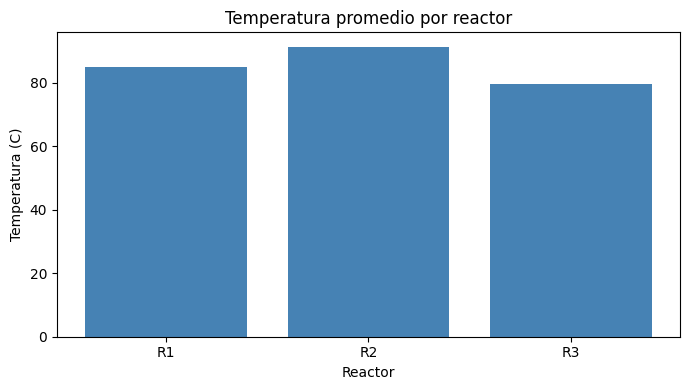

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
datos = {
'reactor': ['R1','R1','R1','R2','R2','R2','R3','R3'],
'turno': ['manana','tarde','noche','manana','tarde','noche','manana','tarde'],
'temperatura': [85, 92, 78, 95, 88, 91, 76, 83],
'eficiencia': [91.2, 87.5, 94.1, 83.3, 89.7, 85.0, 96.4, 92.8],
'incidentes': [0, 1, 0, 2, 0, 1, 0, 0]
}
df = pd.DataFrame(datos)

# Paso 1: calcular los datos a graficar con groupby
promedio_temp = df.groupby('reactor')['temperatura'].mean()
# Paso 2: crear el lienzo (7 pulgadas ancho, 4 alto)
plt.figure(figsize=(7, 4))
# Paso 3: dibujar barras
# .index son los nombres del eje X: R1, R2, R3
# .values son las alturas de las barras: los promedios
plt.bar(promedio_temp.index, promedio_temp.values, color='steelblue')
# Paso 4: etiquetas
plt.title('Temperatura promedio por reactor')
plt.xlabel('Reactor')
plt.ylabel('Temperatura (C)')
plt.tight_layout()
plt.show()

**Ejercicio 3.2 — Grafico de dispersion: temperatura vs eficiencia**

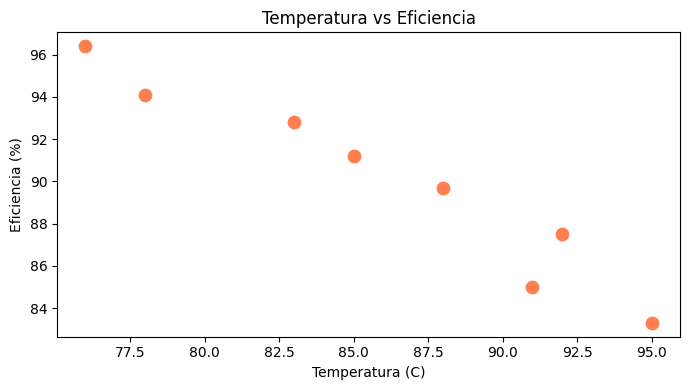

In [ ]:
plt.figure(figsize=(7, 4))

plt.scatter(df['temperatura'], df['eficiencia'], color='coral', s=80)

plt.title('Temperatura vs Eficiencia')
plt.xlabel('Temperatura (C)')
plt.ylabel('Eficiencia (%)')

plt.tight_layout()
plt.show()

**Ejercicio 3.3 — Grafico de linea: eficiencia por medicion**

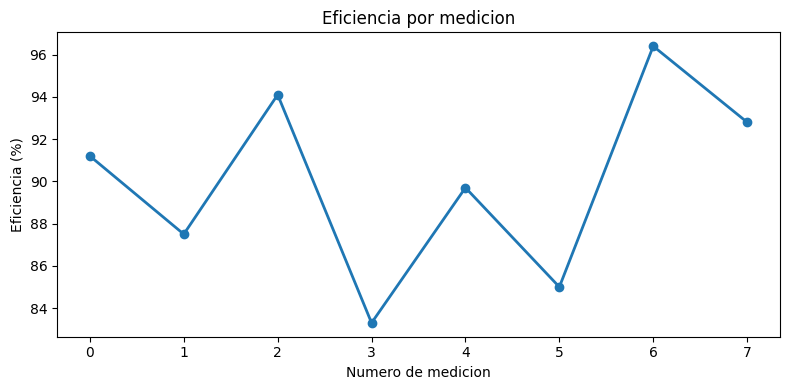

In [20]:
plt.figure(figsize=(8, 4))

plt.plot(df.index, df['eficiencia'], marker='o', linewidth=2)

plt.title('Eficiencia por medicion')
plt.xlabel('Numero de medicion')
plt.ylabel('Eficiencia (%)')

plt.tight_layout()
plt.show()


# bloque4_desafio.py

  reactor   turno  temperatura  eficiencia  incidentes   estado
0      R1  manana           85        91.2           0   normal
1      R1   tarde           92        87.5           1  critico
2      R1   noche           78        94.1           0   normal
3      R2  manana           95        83.3           2  critico
4      R2   tarde           88        89.7           0   normal
5      R2   noche           91        85.0           1  critico
6      R3  manana           76        96.4           0   normal
7      R3   tarde           83        92.8           0   normal
estado
normal     5
critico    3
Name: count, dtype: int64


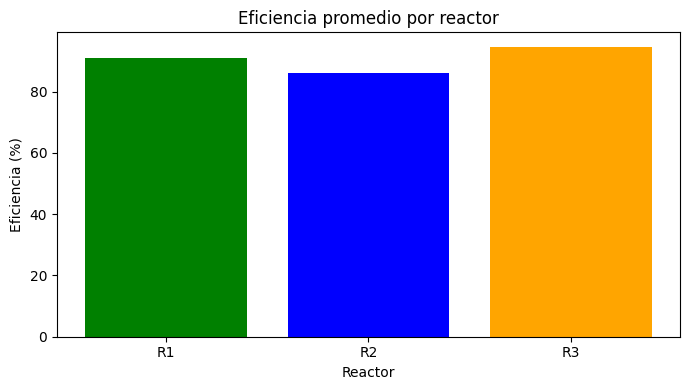

In [34]:
datos = {
'reactor': ['R1','R1','R1','R2','R2','R2','R3','R3'],
'turno': ['manana','tarde','noche','manana','tarde','noche','manana','tarde'],
'temperatura': [85, 92, 78, 95, 88, 91, 76, 83],
'eficiencia': [91.2, 87.5, 94.1, 83.3, 89.7, 85.0, 96.4, 92.8],
'incidentes': [0, 1, 0, 2, 0, 1, 0, 0]
}
df = pd.DataFrame(datos)

estado = []

for t in df['temperatura']:
    if t > 90:
        estado.append('critico')
    else:
        estado.append('normal')

df['estado'] = estado
print(df)

conteo = df['estado'].value_counts()
print(conteo)

promedio = df.groupby('reactor')['eficiencia'].mean()

plt.figure(figsize=(7, 4))
plt.bar(promedio.index, promedio.values, color=['green', 'blue', 'orange'])

plt.title('Eficiencia promedio por reactor')
plt.xlabel('Reactor')
plt.ylabel('Eficiencia (%)')

plt.tight_layout()
plt.show()
